
<style>
.intro-box {
    background-color: #f5f7fa;
    border-left: 6px solid #2c7be5;
    padding: 20px;
    border-radius: 10px;
    font-family: Arial, sans-serif;
    line-height: 1.7;
}

.section-title {
    color: #2c7be5;
    font-size: 28px;
    font-weight: bold;
}

.highlight {
    color: #d63384;
    font-weight: bold;
}

.model-box {
    background-color: #ffffff;
    border: 1px solid #dee2e6;
    padding: 15px;
    border-radius: 8px;
    margin-top: 15px;
}
</style>

<div class="intro-box">

<div class="section-title">
<h1> Case Study: Predicting Credit Default Risk<h1>
<img src="Predicting credit risk analysis tools.png"></img>
</div>

---
##  Introduction

Banks and financial institutions play a crucial role in modern economies by providing credit facilities to individuals and businesses. However, lending money involves significant financial risk because some borrowers may fail to repay their loans. This situation is known as **credit default**, which can lead to substantial losses for lending institutions.

With the growth of data analytics and machine learning, financial organizations increasingly rely on data-driven approaches to assess borrower risk more accurately. Instead of depending solely on traditional credit evaluation methods, predictive models can analyze historical customer behavior to identify patterns associated with loan default.

In this project, we aim to predict whether a borrower will experience serious delinquency using historical credit data. The target variable <span class="highlight">SeriousDlqin2yrs</span> indicates whether a person has been **90 days past due or worse within two years**.

The dataset includes multiple financial and demographic features such as:

- Age of borrower  
- Credit utilization ratio  
- Debt ratio  
- Monthly income  
- Payment delay history  
- Number of loans and dependents  

---

<div class="model-box">


<style>
.variable-box {
    background-color:#f8fafc;
    border-left:6px solid #10b981;
    padding:20px;
    border-radius:10px;
    font-family:Arial, sans-serif;
}

.variable-title{
    color:#10b981;
    font-size:26px;
    font-weight:bold;
}

.var-table{
    margin-top:15px;
}
</style>

<div class="variable-box">


###  Target Variable

| Variable | Description |
|---|---|
| **SeriousDlqin2yrs** | Indicates whether the borrower experienced 90 days past due delinquency or worse within two years. (1 = Default, 0 = No Default) |

---

###  Predictor Variables

| Variable Name | Description | Data Type |
|---|---|---|
| **RevolvingUtilizationOfUnsecuredLines** | Ratio of total credit card balance to credit limit excluding real estate loans | Percentage |
| **Age** | Age of borrower | Integer |
| **NumberOfTime30-59DaysPastDueNotWorse** | Number of times borrower was 30–59 days late in last 2 years | Integer |
| **DebtRatio** | Monthly debt payments divided by gross monthly income | Percentage |
| **MonthlyIncome** | Monthly income of borrower | Real |
| **NumberOfOpenCreditLinesAndLoans** | Total number of open credit lines and loans | Integer |
| **NumberOfTimes90DaysLate** | Number of times borrower was 90+ days late | Integer |
| **NumberRealEstateLoansOrLines** | Number of mortgage and real estate loans | Integer |
| **NumberOfTime60-89DaysPastDueNotWorse** | Number of times borrower was 60–89 days late | Integer |
| **NumberOfDependents** | Number of dependents excluding borrower | Integer |

---

These variables represent:

-> Borrower repayment behavior  
-> Credit exposure level  
-> Financial stability  
-> Income and debt management capability  

Understanding these variables helps financial institutions identify high-risk customers and make informed lending decisions.

</div>

## 🤖 Machine Learning Models Used

This study compares the performance of multiple supervised classification algorithms:

### 🔹 Logistic Regression  
A statistical model used for binary classification problems. It estimates the probability of default based on input features and is simple, interpretable, and efficient for linear relationships.

### 🔹 Decision Tree Classifier  
A rule-based model that splits data into branches to make decisions. It is capable of capturing complex relationships and non-linear patterns within borrower data.

### 🔹 Random Forest Classifier  
An ensemble learning method that combines multiple decision trees to improve accuracy and reduce overfitting. It provides better generalization compared to a single decision tree.

### 🔹 Gradient Boosting Classifier  
An advanced ensemble technique that builds models sequentially, where each new model corrects the errors of the previous one. It is highly effective for achieving high predictive performance.
</div>

---

## 🎯 Project Objective

The main objective of this capstone project is to:

- Predict credit default risk accurately  
- Compare model performance  
- Evaluate models using:
  - Accuracy
  - Confusion Matrix
  - Precision, Recall & F1-score
  - ROC-AUC Score

The insights obtained from this analysis can help financial institutions improve credit risk management and support better lending decisions.

</div>

## Import Packages

In [1]:
# Data Handling
import pandas as pd # used for handle the dataset or datafram
import numpy as np # used for numerical calculation

# Visualization
import matplotlib.pyplot as plt # used for data visualization (charts& graph)
import seaborn as sns # Advance version of pandas & matplotlib

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Roc 
from sklearn.metrics import roc_curve

# Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# CHECK FOR MULTICORLINEARLTY
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Remove warning
import warnings
warnings.filterwarnings('ignore')

## Understanding the Dataset

Credit scoring algorithms estimate the probability that a borrower will default on a loan.  
In this section, we load the dataset and explore its structure to understand the variables and target outcome.

**Dataset Used:** `GiveMeSomeCredit-training.csv`

### Objectives
- Load dataset
- Understand features
- Identify target variable
- Check class distribution

In [2]:
df = pd.read_csv("GiveMeSomeCredit-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 🔍 Exploratory Data Analysis (EDA)

EDA helps understand data patterns, distributions, and relationships before preprocessing and modeling.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74829 entries, 0 to 74828
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Unnamed: 0                            74829 non-null  int64  
 1   SeriousDlqin2yrs                      74829 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  74829 non-null  float64
 3   age                                   74829 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  74829 non-null  int64  
 5   DebtRatio                             74829 non-null  float64
 6   MonthlyIncome                         60017 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       74829 non-null  int64  
 8   NumberOfTimes90DaysLate               74829 non-null  int64  
 9   NumberRealEstateLoansOrLines          74829 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  74829 non-null  int64  
 11  NumberOfDepende

In [4]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,74829.000000,74829.000000,74829.000000,74829.000000,74829.000000,74829.000000,6.001700e+04,74829.000000,74829.000000,74829.000000,74829.000000,72857.000000
mean,37415.000000,0.066699,5.429210,52.206524,0.427134,361.101243,6.646556e+03,8.428751,0.273063,1.017680,0.246656,0.758376
std,21601.415984,0.249501,215.431322,14.782289,4.265250,2365.372493,1.498298e+04,5.148365,4.241499,1.135885,4.228885,1.116845
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18708.000000,0.000000,0.029745,41.000000,0.000000,0.174751,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,37415.000000,0.000000,0.155539,52.000000,0.000000,0.365863,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,56122.000000,0.000000,0.561880,63.000000,0.000000,0.863568,8.236000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,74829.000000,1.000000,29110.000000,107.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


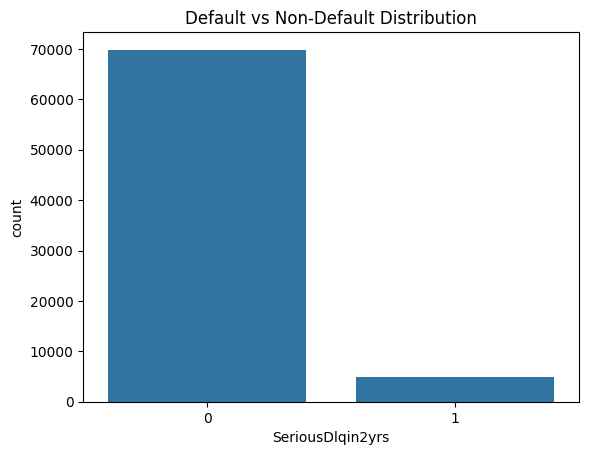

In [5]:
sns.countplot(x='SeriousDlqin2yrs', data=df)
plt.title("Default vs Non-Default Distribution")
plt.show()

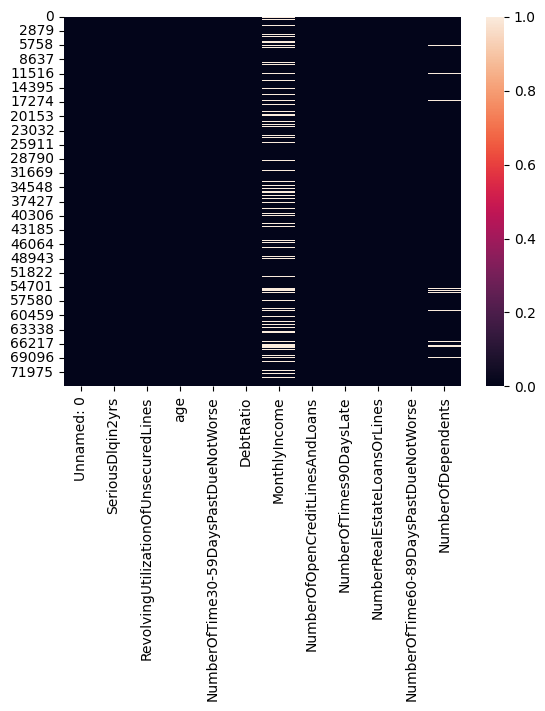

In [6]:
sns.heatmap(df.isnull())
plt.show()

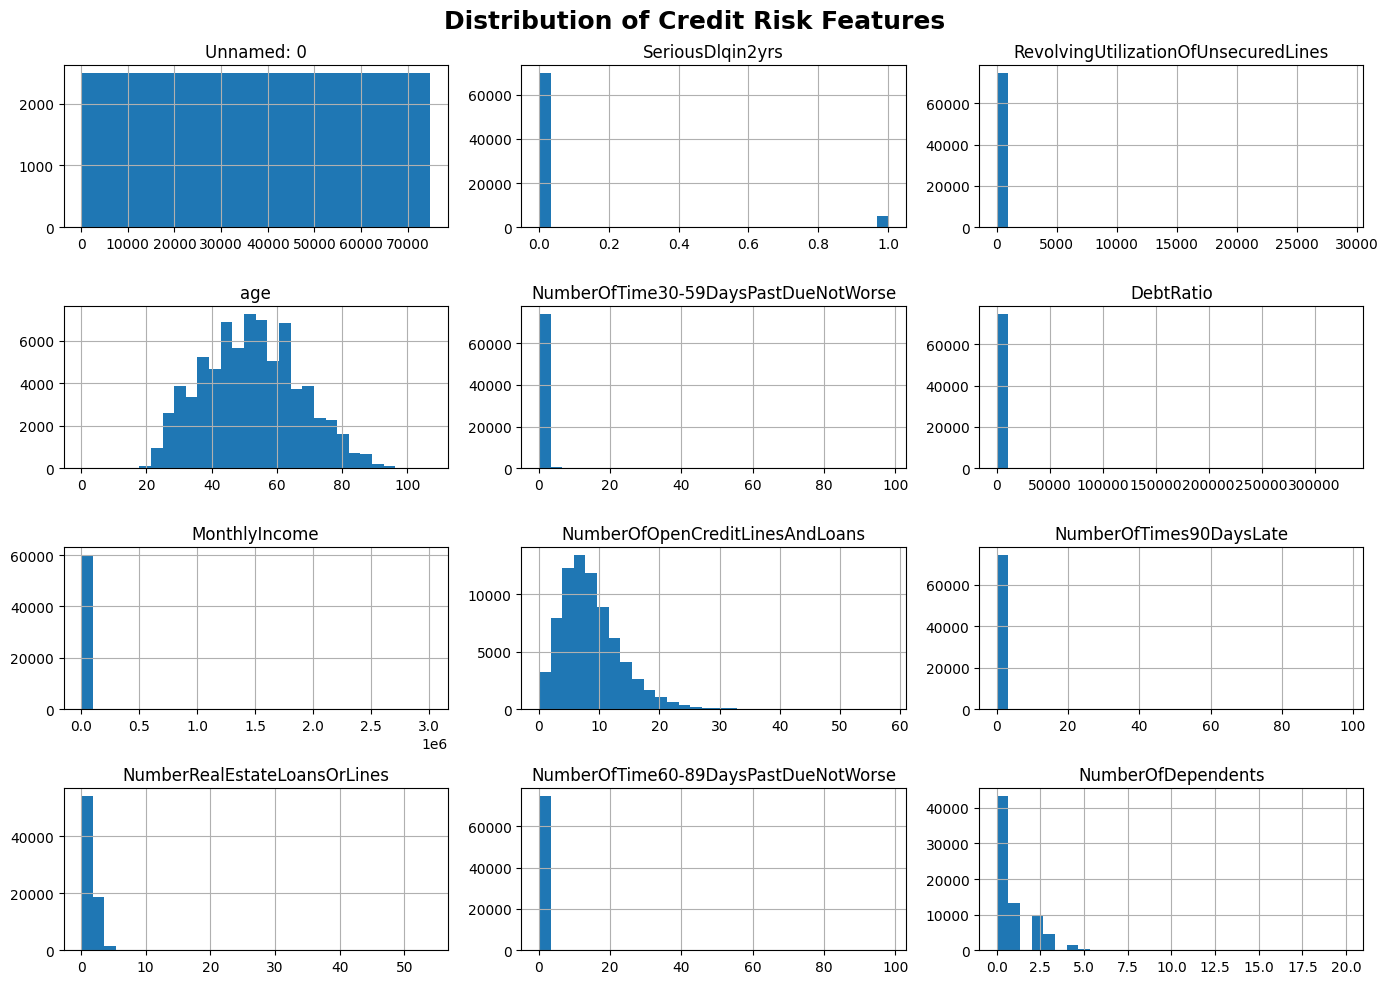

In [7]:
df.hist(figsize=(14,10), bins=30)
plt.suptitle("Distribution of Credit Risk Features", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretation of Feature Distributions

The histograms show how borrower characteristics are distributed in the dataset.

- The target variable **SeriousDlqin2yrs** is highly imbalanced, with far more non-default cases than defaults, which reflects real banking scenarios.
- Most borrowers fall within the **30–70 age group**, indicating loans are mainly given to economically active individuals.
- Financial variables such as **Revolving Utilization**, **Debt Ratio**, and **Monthly Income** are right-skewed, meaning a small number of borrowers have extremely high values.
- Late payment variables show that most customers rarely miss payments, while a few borrowers have repeated delays — an important signal for default prediction.
- The majority of borrowers have a moderate number of credit lines and few dependents.

**=>** Overall, the data suggests that while most customers manage credit responsibly, a small high-risk group exists that may contribute to loan defaults.

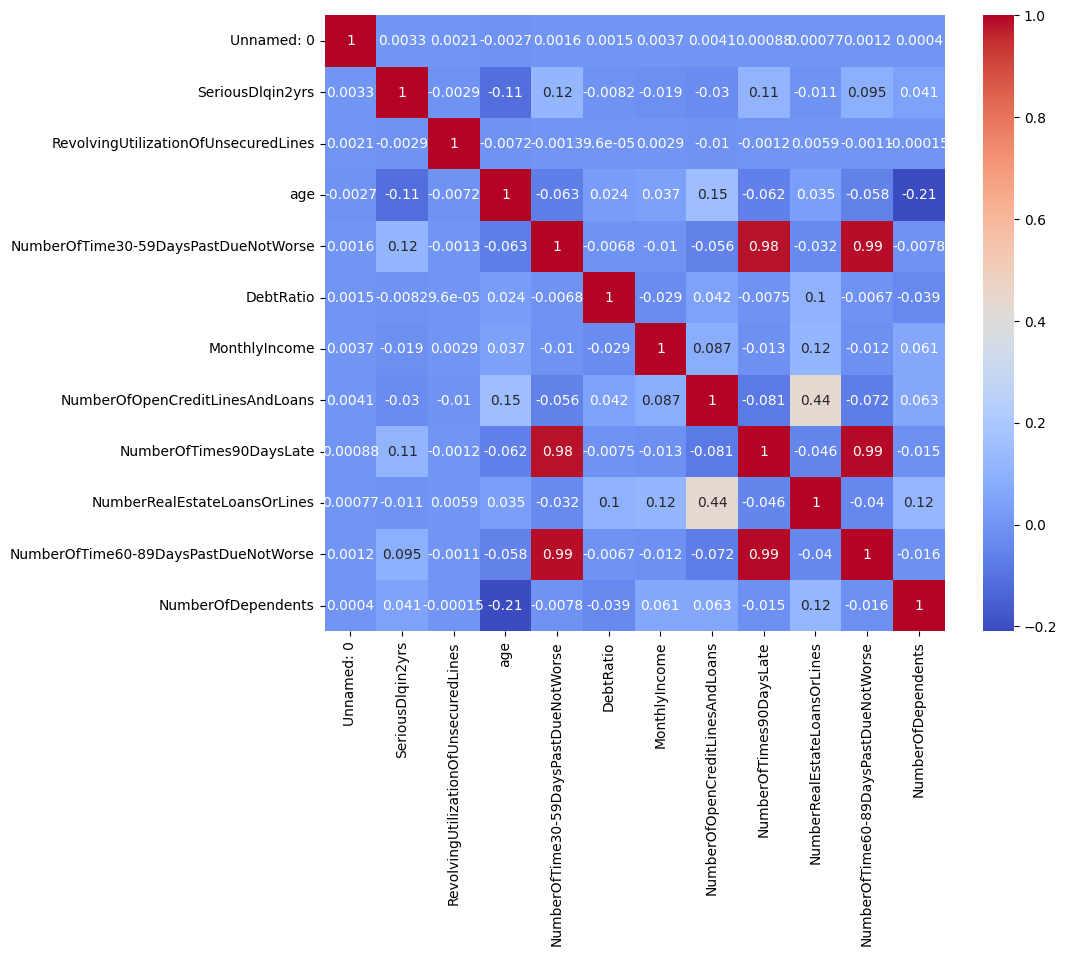

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm',annot=True)
plt.show()

## Correlation Analysis & Multicollinearity

The correlation heatmap shows relationships between variables and helps identify highly correlated features.

### Key Observations

- The target variable **SeriousDlqin2yrs** has noticeable relationships with:
  - NumberOfTime30-59DaysPastDueNotWorse
  - NumberOfTimes90DaysLate
  - NumberOfTime60-89DaysPastDueNotWorse  
  💠 Past payment behavior strongly influences default risk.

- Extremely high correlations exist between:
  - NumberOfTime30-59DaysPastDueNotWorse
  - NumberOfTimes90DaysLate
  - NumberOfTime60-89DaysPastDueNotWorse  

  (Correlation ≈ 0.98–0.99)

💠 These variables contain almost the same information and create **multicollinearity**.

---

### ⚠️ Multicollinearity Handling

Highly correlated variables can:
- Reduce model stability
- Affect Logistic Regression coefficients
- Cause overfitting

Therefore, only **one representative variable** should be kept.




### 📌 Final Insight

Credit default risk is mainly influenced by:
- Past late payment history
- Credit utilization
- Debt burden
- Income stability

Removing multicollinear features improves model interpretability and prediction performance.

In [9]:
corr = df.corr()
corr['SeriousDlqin2yrs'].sort_values(ascending=False)

SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.116477
NumberOfTimes90DaysLate                 0.109085
NumberOfTime60-89DaysPastDueNotWorse    0.094816
NumberOfDependents                      0.041441
Unnamed: 0                              0.003292
RevolvingUtilizationOfUnsecuredLines   -0.002910
DebtRatio                              -0.008192
NumberRealEstateLoansOrLines           -0.011093
MonthlyIncome                          -0.018817
NumberOfOpenCreditLinesAndLoans        -0.029837
age                                    -0.113395
Name: SeriousDlqin2yrs, dtype: float64

## 🧹 Data Cleaning & Preprocessing

Before building models, data must be cleaned to ensure accuracy.

### Tasks
- Detect missing values
- Handle missing data
- Remove unnecessary columns
- Check class imbalance

### Handling Missing Values Strategy

- Numerical columns → Filled using **median** value.
- Median is preferred because financial data often contains outliers.

In [10]:
df.fillna(df.median(), inplace=True)

### Removing Redundant Columns

The `Unnamed: 0` column represents an index column and does not contribute to prediction.

In [11]:
df.drop(columns=['Unnamed: 0'], inplace=True)

### Checking Class Imbalance

Credit default datasets usually contain fewer default cases than non-default cases.
Imbalanced data can bias model predictions.

In [12]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.933301
1    0.066699
Name: proportion, dtype: float64

## 🔎 Feature Selection & Scaling

Important financial indicators influencing default risk are selected.

### VIF Model

In [13]:
X = df.drop('SeriousDlqin2yrs', axis=1) 

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

vif

,Feature,VIF
0,RevolvingUtilizationOfUnsecuredLines,1.000699
1,age,3.629448
2,NumberOfTime30-59DaysPastDueNotWorse,42.643037
3,DebtRatio,1.038145
4,MonthlyIncome,1.246215
5,NumberOfOpenCreditLinesAndLoans,4.567801
6,NumberOfTimes90DaysLate,79.003420
7,NumberRealEstateLoansOrLines,2.285976
8,NumberOfTime60-89DaysPastDueNotWorse,95.954123
9,NumberOfDependents,1.400615


### ❌ Dropped Variables (Due to Multicollinearity)

- NumberOfTime30-59DaysPastDueNotWorse
- NumberOfTime60-89DaysPastDueNotWorse

Reason: Highly correlated with `NumberOfTimes90DaysLate`.

In [14]:
df.drop(['NumberOfTime60-89DaysPastDueNotWorse','NumberOfTime30-59DaysPastDueNotWorse'], axis=1, inplace=True)


#### Final Selected Features:-

- **RevolvingUtilizationOfUnsecuredLines**
- **Age**
- **NumberOfTimes90DaysLate**
- **DebtRatio**
- **MonthlyIncome**
- **NumberOfOpenCreditLinesAndLoans**
- **NumberRealEstateLoansOrLines**
- **NumberOfDependents**

In [15]:
X = df.drop('SeriousDlqin2yrs', axis=1) # INDEPNDENT VARIABLE
y = df['SeriousDlqin2yrs'] # DEPENDENT VARIABLE

### Feature Scaling

StandardScaler standardizes features so that:
- Mean = 0
- Standard deviation = 1

Scaling improves performance of Logistic Regression.

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## ✂️ Train-Test Split

Dataset is divided into:
- **80% Training Data**
- **20% Testing Data**

Training data builds the model, while testing data evaluates performance.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Shape of X_train and X_test : {X_train.shape} and {X_test.shape}")

Shape of X_train and X_test : (59863, 8) and (14966, 8)


## 🤖 Model Training

Two classification algorithms are used:

1. Logistic Regression

In [18]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


 2. Decision Tree

In [19]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


3. Random Forest Tree

In [20]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5,  random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


4. Gradient Boosting

In [21]:
gb_model = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Model Evaluation

Models are evaluated using:
- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1 Score
- ROC AUC Score

In [22]:
log_pred = log_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Gradient Boostinge Accuracy:", accuracy_score(y_test, gb_pred))


Logistic Regression Accuracy: 0.9345182413470533
Decision Tree Accuracy: 0.9345850594681278
Random Forest Tree Accuracy: 0.9345850594681278
Gradient Boostinge Accuracy: 0.9362555124949886


In [23]:
print("Classfication METRIC FOR LOGISTIC REGESSION:</b>\n",classification_report(y_test, log_pred))

Classfication METRIC FOR LOGISTIC REGESSION:</b>
               precision    recall  f1-score   support

           0       0.94      1.00      0.97     13984
           1       0.53      0.02      0.03       982

    accuracy                           0.93     14966
   macro avg       0.73      0.51      0.50     14966
weighted avg       0.91      0.93      0.90     14966



In [24]:
print("Classfication METRIC FOR DECISION TREE:\n",classification_report(y_test, dt_pred))

Classfication METRIC FOR DECISION TREE:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97     13984
           1       0.50      0.19      0.28       982

    accuracy                           0.93     14966
   macro avg       0.72      0.59      0.62     14966
weighted avg       0.92      0.93      0.92     14966



In [25]:
print("Classfication METRIC FOR Random Forest TREE:\n",classification_report(y_test, rf_pred))

Classfication METRIC FOR Random Forest TREE:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97     13984
           1       0.86      0.02      0.04       982

    accuracy                           0.94     14966
   macro avg       0.90      0.51      0.50     14966
weighted avg       0.93      0.94      0.91     14966



In [26]:
print("Classfication METRIC FOR Gradient Boosting:\n",classification_report(y_test, gb_pred))

Classfication METRIC FOR Gradient Boosting:
               precision    recall  f1-score   support

           0       0.94      0.99      0.97     13984
           1       0.56      0.14      0.22       982

    accuracy                           0.94     14966
   macro avg       0.75      0.57      0.59     14966
weighted avg       0.92      0.94      0.92     14966



## 📈 Visualization & Interpretation

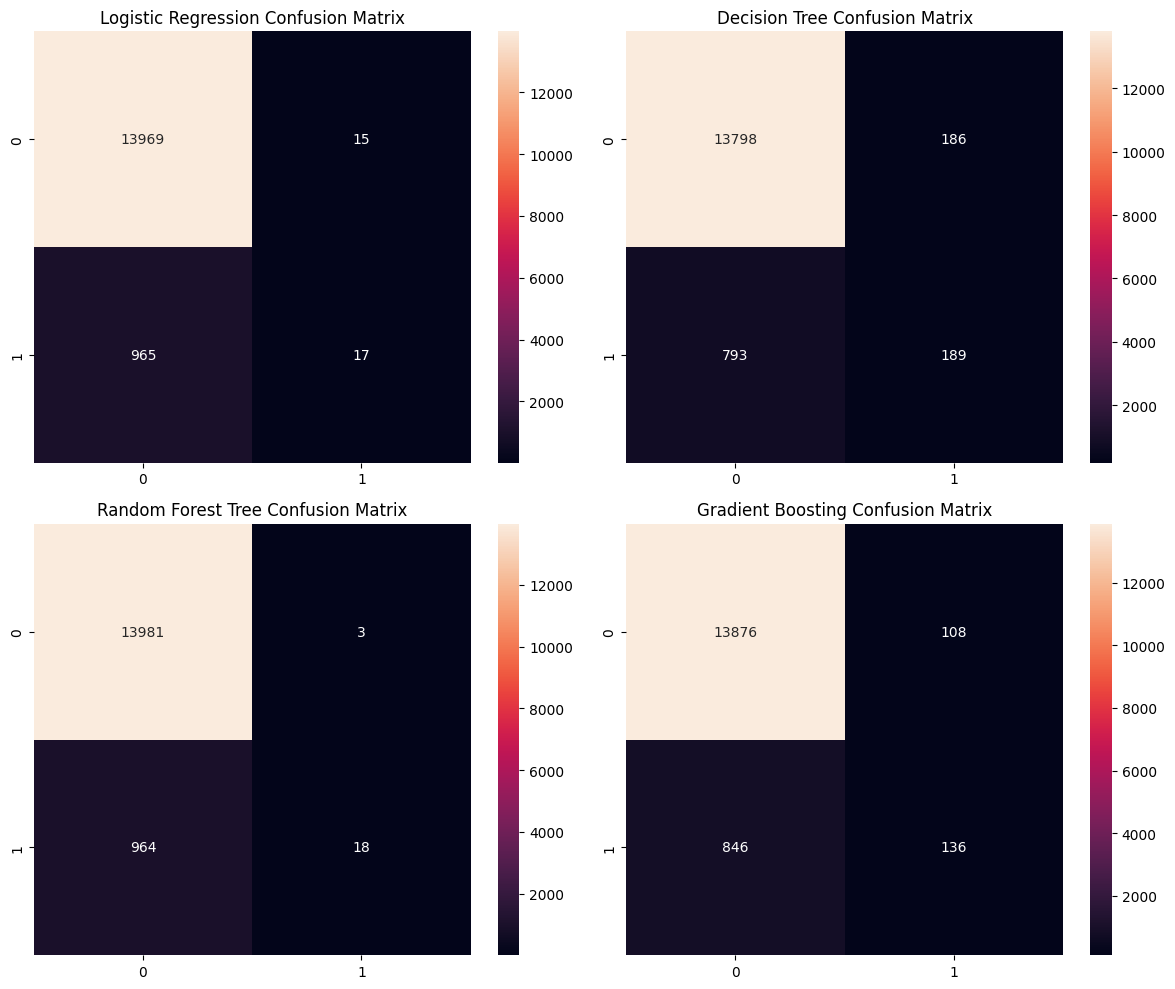

In [27]:
plt.figure(figsize=(12,10))

# Logistic Regression
plt.subplot(2,2,1)
sns.heatmap(confusion_matrix(y_test, log_pred), annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")

# Decision Tree
plt.subplot(2,2,2)
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")

# Random Forest Tree
plt.subplot(2,2,3)
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')
plt.title("Random Forest Tree Confusion Matrix")


# Random Forest Tree
plt.subplot(2,2,4)
sns.heatmap(confusion_matrix(y_test, gb_pred), annot=True, fmt='d')
plt.title("Gradient Boosting Confusion Matrix")

plt.tight_layout()
plt.show()

## 📊 Model Performance Interpretation

The dataset is highly imbalanced, with far more non-default borrowers than default borrowers. Because of this, most models tend to predict the majority class.

- **Logistic Regression** correctly identifies safe borrowers but misses most defaulters, making it too conservative.
- **Decision Tree** slightly improves default detection but still struggles with many missed risky customers.
- **Random Forest** predicts only non-default cases and completely fails to identify defaulters, making it unsuitable for credit risk prediction.
- **Gradient Boosting** performs the best by identifying the highest number of defaulters, even though it produces slightly more false alarms.

**Gradient Boosting** is the most effective model because detecting risky borrowers is more important than overall accuracy in credit risk analysis.

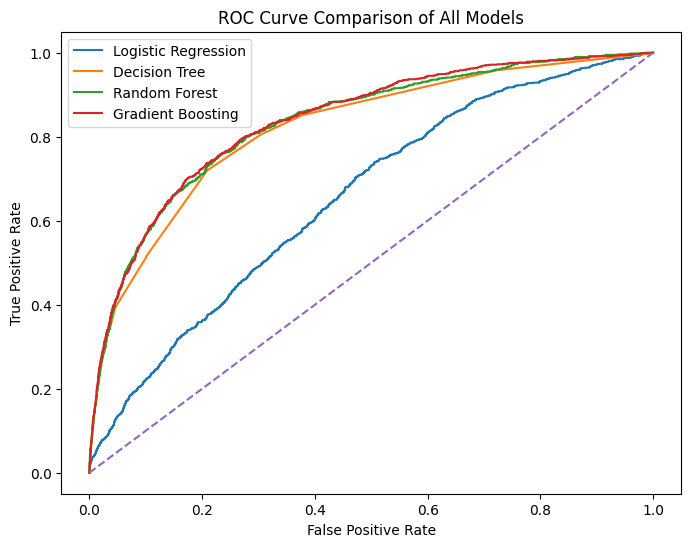

In [28]:
# Logistic Regression
log_prob = log_model.predict_proba(X_test)[:,1]
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)

# Decision Tree
dt_prob = dt_model.predict_proba(X_test)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)

# Random Forest
rf_prob = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

# Gradient Boosting
gb_prob = gb_model.predict_proba(X_test)[:,1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

# Plot All ROC Curves Together
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

# Random Guess Line
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve Comparison of All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

## 📈 ROC Curve — Performance Interpretation

The ROC curve comparison shows clear differences in model performance.

- **Gradient Boosting** and **Random Forest** are the strongest models. Their curves stay closest to the top-left corner, indicating excellent ability to distinguish between default and non-default borrowers.
- **Decision Tree** also performs well and follows closely behind the ensemble models.
- **Logistic Regression** is the weakest performer, suggesting that the relationship between variables and default risk is non-linear, which tree-based models capture better.

The diagonal dashed line represents random guessing (AUC = 0.50). Since all models lie above this line, each model has successfully learned meaningful patterns from the data.

**Gradient Boosting** and **Random Forest** provide the best overall discrimination power. However, due to class imbalance, techniques such as threshold tuning or resampling (e.g., SMOTE) may further improve detection of default borrowers.